In [1]:
#%pip install --upgrade shap

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as utils_data
from torch.autograd import Variable

import shap

from sklearn.preprocessing import MinMaxScaler 
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

import pickle
import json
import os
import warnings
import datetime

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"{torch.cuda.device_count()} GPU(s) available and will be used.\nGPU name(s): {[torch.cuda.get_device_name(n) for n in range(torch.cuda.device_count())]}")
else:
    device = torch.device("cpu")
    print("GPU not available, using CPU.")

1 GPU(s) available and will be used.
GPU name(s): ['Tesla V100-PCIE-16GB']


In [4]:
RANDOM_STATE = 42

In [5]:
class tanh_MLP(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, output_size):
        super(tanh_MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.fc3 = nn.Linear(hidden_size2, output_size)
        
    def forward(self, x):
        x = F.tanh(self.fc1(x))
        x = F.tanh(self.fc2(x))
        out = self.fc3(x)
        return out

In [6]:
# Instantiate a dataframe on first dataset to get columns
nfl_df = pd.read_csv('../dataset_generators/datasets/0_train_normalized.csv')
# Get normalized columns
y = ['fantasy_points']
X = [col for col in nfl_df.columns if col not in ('player_id'
                                                        , 'player_name'
                                                        , 'player_display_name'
                                                        , 'position','position_group'
                                                        , 'headshot_url'
                                                        , 'season'
                                                        , 'week'
                                                        , 'season_type'
                                                        , 'team'
                                                        , 'opponent_team'
                                                        , 'fantasy_points'
                                                        , 'Unnamed: 0')]
del nfl_df

In [18]:
ablation_col_lst = [[col for col in X if 'avg_1' in col]
                    ,[col for col in X if 'avg_3' in col]
                    ,[col for col in X if 'avg_5' in col]
                    ,[col for col in X if 'avg_8' in col]]

In [19]:
# The best model is the one below
model = '_100-100_tanh_100_0.0001_norm.pickle'


train_dataset_name = '_train_normalized.csv'
test_dataset_name = '_test_normalized.csv'

all_shap_values = []
all_inputs = []

feature_importances_dict = {}
# Iterate over all 5 versions of the model that were trained on the KFold cross validation sets
for n in range(5):
    # Load the model    
    model_name = f'../model_generators/mlp/models/{n}{model}'
    with open(model_name, 'rb') as f:
        #print(model)
        mlp = pickle.load(f)
        mlp.eval()
    # Get the scaler
    train_data_df = pd.read_csv(f'../dataset_generators/datasets/{n}{train_dataset_name}')
    test_data_df = pd.read_csv(f'../dataset_generators/datasets/{n}{test_dataset_name}')
    new_train_df_x = train_data_df[X]
    new_test_df_x = test_data_df[X]
    new_test_df_y = test_data_df[y]
    with torch.no_grad():
        y_pred = mlp(torch.tensor(new_test_df_x.values, dtype=torch.float32)).squeeze()
        baseline_score = mean_absolute_error(new_test_df_y, y_pred.cpu().numpy())
    
    ablation_feature = {}
    num_features = len(X)
    
    for cols in ablation_col_lst:
        X_ablated = new_test_df_x.copy()
        for col in cols:
            X_ablated[col] = 0
        with torch.no_grad():
            ablated_preds = mlp(torch.tensor(X_ablated.values, dtype=torch.float32)).squeeze()
            ablated_score = mean_absolute_error(new_test_df_y, ablated_preds.cpu().numpy())
        
        if 'avg_1' in cols[0]:
            key = 'avg_1'
        elif 'avg_3' in cols[0]:
            key = 'avg_3'
        elif 'avg_5' in cols[0]:
            key = 'avg_5'
        elif 'avg_8' in cols[0]:
            key = 'avg_8'
        else:
            raise Exception("...Where'd you get these columns? They should be avg_1,3,5,8...")
        ablation_feature[key] = ablated_score
        ablation_feature['baseline'] = baseline_score
    
    feature_importances_dict[n] = ablation_feature


In [39]:
fin_ablation = []
for n in ['avg_1','avg_3','avg_5','avg_8','baseline']:
    avg_ablation = feature_importances_dict[0][n] + feature_importances_dict[1][n] + feature_importances_dict[2][n] + feature_importances_dict[3][n] + feature_importances_dict[4][n]
    avg_ablation = avg_ablation/5
    
    fin_ablation.append((n, avg_ablation))

In [41]:
fi_df = pd.DataFrame(fin_ablation, columns=['feature_group','MAE'])

In [45]:
fi_df.sort_values('MAE',ascending=False)

,feature_group,MAE
3,avg_8,4.769469
4,baseline,3.812106
2,avg_5,3.726455
0,avg_1,3.688057
1,avg_3,3.681215


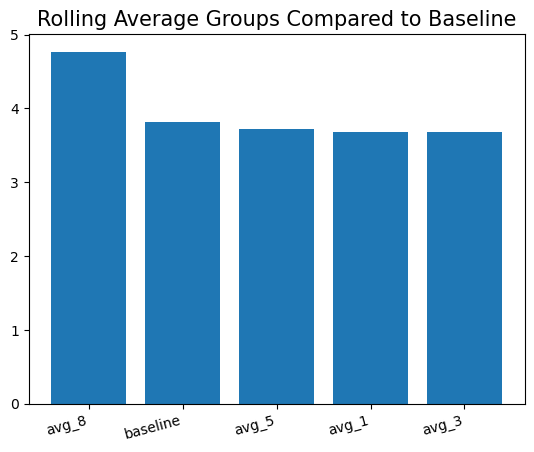

In [42]:
fi_df = fi_df.sort_values('MAE',ascending=False)
fi_df_top10 = fi_df.iloc[:5]
plt.bar(fi_df_top10['feature_group'], fi_df_top10['MAE'])
plt.xticks(rotation=15, ha='right')
plt.title('Rolling Average Groups Compared to Baseline', fontsize=15)
plt.show()